<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
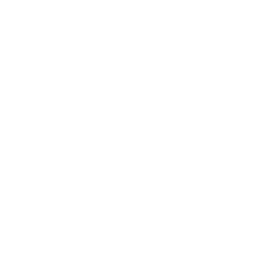
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">熱間圧延ミルの圧延工程監視</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 熱間圧延ミルの板厚・表面品質管理のための多変量SPC &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## エグゼクティブサマリー

熱間圧延ミルは鋼スラブを薄いコイルへ圧延する設備である。相関を持つ6つの工程信号（板厚、圧延荷重、ロールギャップ、モーター電流、出側温度）はラインが健全なときには一体となって変動するため、1つのチャートずつ監視していると重要な同時変化を見逃してしまう。本例では **PROC MVPMODEL** で多変量ベースラインモデルを構築し、続いて **PROC MVPMONITOR** で100本の量産コイルをストリーム処理し、各コイルを単一のホテリングの *T*&sup2; 統計量でスコアリングして管理限界と比較する。

α = 0.05 における管理内限界 *T*&sup2; = **17.13** に対して、**100本中4本のコイル**が管理外を示した — コイル **91、92、94、95** で、これはちょうどバックアップロールのびびり振動バーストを注入した区間と一致する。ピークの *T*&sup2; はコイル95で **21.91** に達し、限界の約 **1.3倍** である。後半のコイルにかけて緩やかに進行するロール摩耗はベースラインの *T*&sup2; を押し上げるが、びびり振動イベントが発生するまでは限界を下回ったままであり、この単一のチャートによって直ちに対応が必要な急性故障と緩やかなドリフトが明確に区別される。

## データソース

- **mill_baseline** &mdash; キャンペーン中の既知の良好期間に圧延された50本のコイル。多変量（PCA）基準モデルの当てはめに使用する。
- **mill_stream** &mdash; 実ラインからの100本のコイル。コイル1&ndash;55は管理内で稼働し、コイル56&ndash;100にかけてロール摩耗が緩やかに進行し、コイル91&ndash;95でバックアップロールのびびり振動バーストが発生する。
- **工程変数**（6個）: `entry_thickness`、`exit_thickness`、`rolling_force`、`roll_gap`、`motor_current`、`exit_temp`。

> 本環境はライセンスなしで動作するため、データセットは100件までに制限される。シナリオはこの上限に合わせて設計されており、外乱は5000本中2800本目ではなく、100本のストリームの終盤に配置されている。

---

### ステップ1 &mdash; 多変量基準モデルの構築

`PROC MVPMODEL` は、管理内ベースライン上で6つの工程変数の主成分分析を実行し、負荷量、固有値、中心化・尺度化の情報を `mill_model` に書き出す。3個の主成分を保持する。このモデルは、「正常」がどのようなものかを、6つの独立した範囲ではなく、単一の多変量領域として定義する。

In [1]:
データ mill_baseline;
  呼出 streaminit(66);
  繰返 coil_id = 1 から 50;
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + rand('normal', 0, 0.030);
    rolling_force   = 18000 + rand('normal', 0, 150);
    roll_gap        =  2.85 + rand('normal', 0, 0.015);
    motor_current   =   850 + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    出力;
  終了;
実行;

処理 mvpmodel データ=mill_baseline outmodel=mill_model;
  変数 entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  ncomp=3;
実行;



                    The MVPMODEL Procedure

  Data Set:          mill_baseline
  Number of Variables: 6
  Missing Value Handling: Exclude
  Number of Observations Read: 50
  Number of Observations Used: 50
  Number of Principal Components: 3

  Correlation Matrix
         entry_thicknessexit_thicknessrolling_force  roll_gapmotor_current exit_temp
  entry_thickness    1.0000   -0.0416   -0.1641   -0.1661    0.1555    0.0649
  exit_thickness   -0.0416    1.0000    0.0406    0.0029    0.0946   -0.1421
  rolling_force   -0.1641    0.0406    1.0000   -0.1351    0.2077   -0.0051
  roll_gap   -0.1661    0.0029   -0.1351    1.0000   -0.0510   -0.0876
  motor_current    0.1555    0.0946    0.2077   -0.0510    1.0000    0.1587
  exit_temp    0.0649   -0.1421   -0.0051   -0.0876    0.1587    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 1.37232115  0.14267284    0.2287    0.2287
    2 1.22964831  0.16747324    0.2049    0.4337
    3


NOTE: DATA mill_baseline


NOTE: Wrote mill_baseline (50 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


---

### ステップ2 &mdash; 量産コイルをストリームしてスコアリングする

`PROC MVPMONITOR` は、100本の量産コイルそれぞれを保存済みモデルに投影し、ホテリングの *T*&sup2; を計算する。本プロシジャはモデルの次元と既定の α = 0.05 から管理限界を導出し、それを超えるコイルにフラグを立てる。`_TSQUARED`、`_LIMIT`、`_SIGNAL` の各列を含む結果は、`coil_id` をキーとして `mill_scores` に書き出される。

In [2]:
データ mill_stream;
  呼出 streaminit(42);
  繰返 coil_id = 1 から 100;
    /* ロール摩耗はコイル56-100にかけて0から1へ上昇 */
    wear    = max(0, coil_id - 55) / 45;
    /* コイル91-95でバックアップロールのびびり振動バーストが発生 */
    chatter = (coil_id >= 91 かつ coil_id <= 95);
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + wear*0.10 + chatter*0.35
                            + rand('normal', 0, 0.030);
    rolling_force   = 18000 + wear*600  + chatter*1600
                            + rand('normal', 0, 150);
    roll_gap        =  2.85 + wear*0.055
                            + rand('normal', 0, 0.015);
    motor_current   =   850 + wear*38   + chatter*95
                            + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    削除 wear chatter;
    出力;
  終了;
実行;

処理 mvpmonitor データ=mill_stream 模型=mill_model
                out=mill_scores;
  変数 entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  id coil_id;
実行;



                    The MVPMONITOR Procedure

  Variables:       6
  Observations:    100
  T2 Limit:        17.1334
  Signals:         4





NOTE: DATA mill_stream


NOTE: Wrote mill_stream (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MVPMONITOR
NOTE: PROC MVPMONITOR statement used.


本プロシジャのサマリーには管理限界とシグナル件数が示される。以下に印刷される、外乱付近のスライスでは、ベースラインのコイルは限界を大きく下回っている一方、びびり振動の区間では4本のコイルが限界を上回っていることが分かる。

In [3]:
/* 管理外コイルにフラグを立て、プロット用にアラームT2を取得する */
データ mill_scores;
  設定 mill_scores;
  もし _SIGNAL = 1 なら t2_alarm = _TSQUARED;
  他 t2_alarm = .;
実行;

処理 印刷 データ=mill_scores(firstobs=88 obs=96) noobs;
  変数 coil_id _TSQUARED _LIMIT _SIGNAL;
  見出 coil_id='コイルID' _TSQUARED='T2統計量' _LIMIT='管理限界' _SIGNAL='シグナル';
  表題 'びびり振動区間におけるT2スコア(コイル88-96)';
実行;


                                               びびり振動区間におけるT2スコア(コイル88-96)                                               

      コイルID        T2統計量          管理限界          シグナル
         88     9.983151     17.133408             0
         89     2.915646     17.133408             0
         90      7.80613     17.133408             0
         91    18.813814     17.133408             1
         92    18.249361     17.133408             1
         93    16.638221     17.133408             0
         94    17.981792     17.133408             1
         95    21.912329     17.133408             1
         96     5.118574     17.133408             0

... 4 more observations (showing 9 of 13)




NOTE: DATA mill_scores


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_scores (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC PRINT data=mill_scores

NOTE: PROC PRINT completed: 9 observations printed, 4 variables


---

### ステップ3 &mdash; 多変量管理図

このチャートは、各コイルの *T*&sup2; を管理限界と重ねて表示する。管理外のコイルは赤で強調表示され、破線の垂直マーカーはびびり振動バーストの開始位置を示す。右側にかけての緩やかな上昇はロール摩耗がベースラインを押し上げているものであり、4つの赤い点は急性のびびり振動故障を示す。

                                               びびり振動区間におけるT2スコア(コイル88-96)                                               




NOTE: PROC SGPLOT data=mill_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


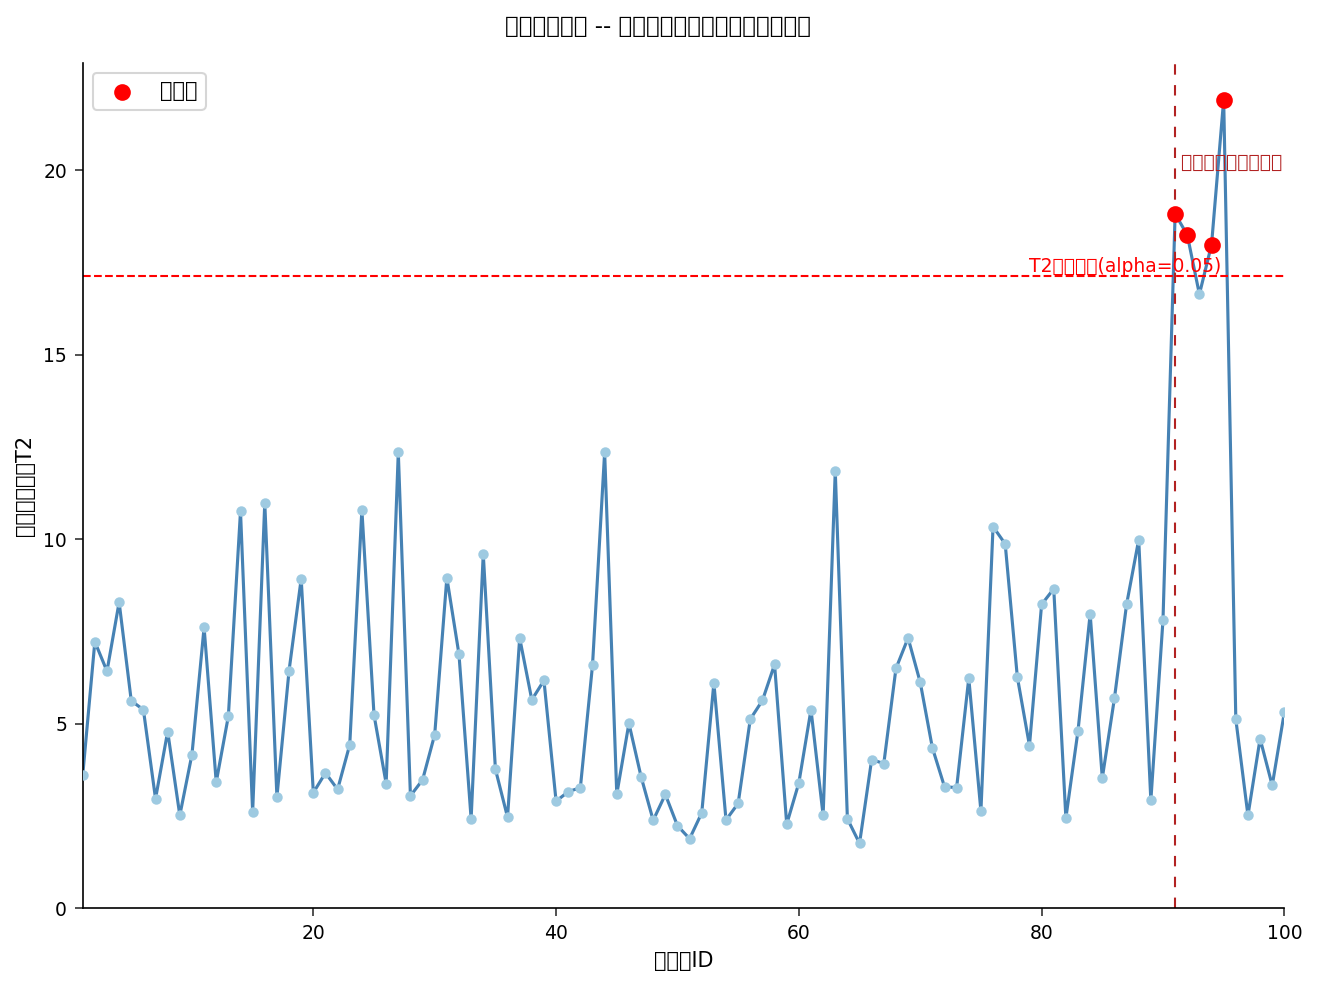

In [4]:
処理 SGPLOT データ=mill_scores;
  SERIES  x=coil_id y=_TSQUARED /
          LINEATTRS=(color=steelblue thickness=1.5);
  SCATTER x=coil_id y=_TSQUARED /
          MARKERATTRS=(SYMBOL=circlefilled size=4 color=cx9ecae1);
  SCATTER x=coil_id y=t2_alarm /
          MARKERATTRS=(SYMBOL=circlefilled size=7 color=red)
          legendlabel='管理外';
  REFLINE _LIMIT / AXIS=y
          見出='T2管理上限(alpha=0.05)'
          LINEATTRS=(color=red pattern=dash);
  REFLINE 91 / AXIS=x 見出='びびり振動バースト'
          LINEATTRS=(color=firebrick pattern=shortdash);
  XAXIS 見出='コイルID' MIN=1 MAX=100;
  YAXIS 見出='ホテリングのT2' MIN=0;
  表題 '熱間圧延ミル -- ロール摩耗とびびり振動の検出';
実行;


---

### ステップ4 &mdash; 管理外コイルの定量化

管理外のコイルは、品質管理部門向けに別のデータセットへ振り分けられる。`PROC MEANS` は、フラグの立ったコイルの *T*&sup2; 水準を管理内の母集団と対比し、フラグの立ったコイルはその後のスクラップ／手直しルーティングのためにエクスポートされる。

In [5]:
データ mill_ooc;
  設定 mill_scores;
  もし _SIGNAL = 1;
実行;

処理 平均 データ=mill_scores n mean max maxdec=2;
  分類 _SIGNAL;
  変数 _TSQUARED;
  見出 _SIGNAL='管理状態' _TSQUARED='T2統計量';
  表題 '管理状態別のT2(0 = 管理内, 1 = シグナル)';
実行;

処理 印刷 データ=mill_ooc noobs;
  変数 coil_id _TSQUARED _LIMIT;
  見出 coil_id='コイルID' _TSQUARED='T2統計量' _LIMIT='管理限界';
  表題 '検査対象としてフラグが立てられた管理外コイル';
実行;

処理 EXPORT データ=mill_ooc
            OUTFILE='steel_mill_ooc_coils.csv'
            DBMS=csv REPLACE;
実行;


                                              管理状態別のT2(0 = 管理内, 1 = シグナル)                                               

                                                  The MEANS Procedure

                                       Analysis Variable : _TSQUARED T2統計量

        管理状態                  N Obs           Mean        Maximum
        ---------------------------------------------------------
        0                        96           5.39          16.64
        1                         4          19.24          21.91
        ---------------------------------------------------------

                                                 検査対象としてフラグが立てられた管理外コイル                                                 

      コイルID        T2統計量          管理限界
         91    18.813814     17.133408
         92    18.249361     17.133408
         94    17.981792     17.133408
         95    21.912329     17.133408




NOTE: DATA mill_ooc


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_ooc (4 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=mill_ooc

NOTE: PROC PRINT completed: 4 observations printed, 3 variables
NOTE: PROC EXPORT data=mill_ooc outfile=steel_mill_ooc_coils.csv

NOTE: Exported 4 rows to steel_mill_ooc_coils.csv.


## 結果のまとめ

- **監視したコイル数**: 100本、**管理限界** *T*&sup2; = **17.13**（α = 0.05）。
- **管理外コイル**: **4本** &mdash; コイル **91、92、94、95** で、いずれも注入されたびびり振動区間（91&ndash;95）内にある。コイル93は *T*&sup2; = 16.64 とピークに達するが、限界にはわずかに届かない。
- **最大深刻度**: コイル95で *T*&sup2; = **21.91**（限界の約1.3倍）に達し、管理内コイルの平均は *T*&sup2; &asymp; **5.4** である。
- **摩耗と故障の違い**: 緩やかなロール摩耗ランプは後半コイルのベースラインを押し上げるが、単独で限界を超えることはなく、この単一の多変量チャートによって緩やかなドリフト（要監視）と急性のびびり振動イベント（要対応）とを区別できる。
- **対応**: フラグが立った4本のコイルは検査およびスクラップ／手直しルーティングのために `steel_mill_ooc_coils.csv` にエクスポートされる。びびり振動の兆候は、次回キャンペーン前に検査すべきバックアップロール軸受を示している。

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 機密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
<a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a> 提供
</div>
</div>